In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [3]:
import os

train_path = "/kaggle/input/brain-tumor-mri-dataset/Training"

print(os.listdir(train_path))

['pituitary', 'notumor', 'meningioma', 'glioma']


In [4]:
import shutil

source = "/kaggle/input/brain-tumor-mri-dataset"
destination = "/content/brain-tumor-mri-dataset"

shutil.copytree(source, destination, dirs_exist_ok=True)

print("Dataset copied successfully!")

Dataset copied successfully!


In [5]:
import os

print(os.listdir("/content/brain-tumor-mri-dataset"))

['Training', 'Testing']


# Images count check

In [6]:
import os

base_path = "/content/brain-tumor-mri-dataset"

for folder in ["Training", "Testing"]:
    print("\n", folder)

    folder_path = os.path.join(base_path, folder)

    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        count = len(os.listdir(class_path))
        print(class_name, ":", count)


 Training
meningioma : 1400
pituitary : 1400
notumor : 1400
glioma : 1400

 Testing
meningioma : 400
pituitary : 400
notumor : 400
glioma : 400


**MRI Images Check**

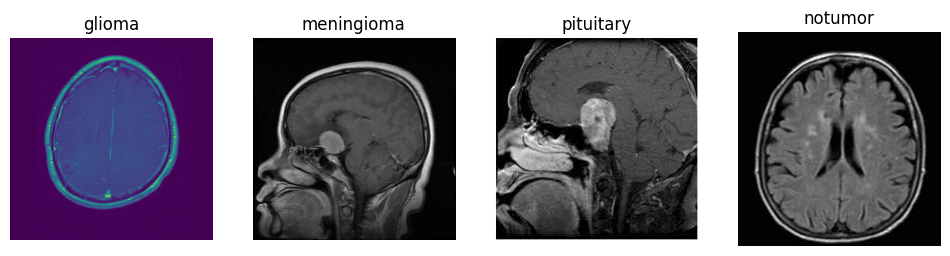

In [7]:
import matplotlib.pyplot as plt
import os
from PIL import Image

base_path = "/content/brain-tumor-mri-dataset/Training"

classes = ["glioma", "meningioma", "pituitary", "notumor"]

plt.figure(figsize=(12, 4))

for i, class_name in enumerate(classes):
    folder = os.path.join(base_path, class_name)
    image_name = os.listdir(folder)[0]
    image_path = os.path.join(folder, image_name)

    image = Image.open(image_path)

    plt.subplot(1, 4, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [8]:
train_path = "/content/brain-tumor-mri-dataset/Training"
test_path = "/content/brain-tumor-mri-dataset/Testing"

print("Training path:", train_path)
print("Testing path:", test_path)

Training path: /content/brain-tumor-mri-dataset/Training
Testing path: /content/brain-tumor-mri-dataset/Testing


# Image Preprocessing

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [10]:
import tensorflow as tf

model = tf.keras.Sequential([

    # Input
    tf.keras.layers.Input(shape=(224, 224, 3)),

    # Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    # Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    # Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.30),

    # Block 4
    tf.keras.layers.Conv2D(256, (3, 3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.30),

    # Classifier
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.50),

    # Output
    tf.keras.layers.Dense(4, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,829,828 (37.50 MB)

 Trainable params: 9,828,356 (37.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [11]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [12]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print("Early stopping ready!")

Early stopping ready!


In [13]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=5,
    callbacks=[early_stopping]
)

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 93s 450ms/step - accuracy: 0.7405 - loss: 0.7143 - val_accuracy: 0.2831 - val_loss: 10.6549
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 78s 443ms/step - accuracy: 0.7966 - loss: 0.5386 - val_accuracy: 0.2856 - val_loss: 3.5670
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 77s 436ms/step - accuracy: 0.8268 - loss: 0.4656 - val_accuracy: 0.4650 - val_loss: 1.5262
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 78s 444ms/step - accuracy: 0.8389 - loss: 0.4347 - val_accuracy: 0.4469 - val_loss: 4.2351
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 76s 435ms/step - accuracy: 0.8443 - loss: 0.4128 - val_accuracy: 0.7750 - val_loss: 0.8095


# Training & Validation Graph

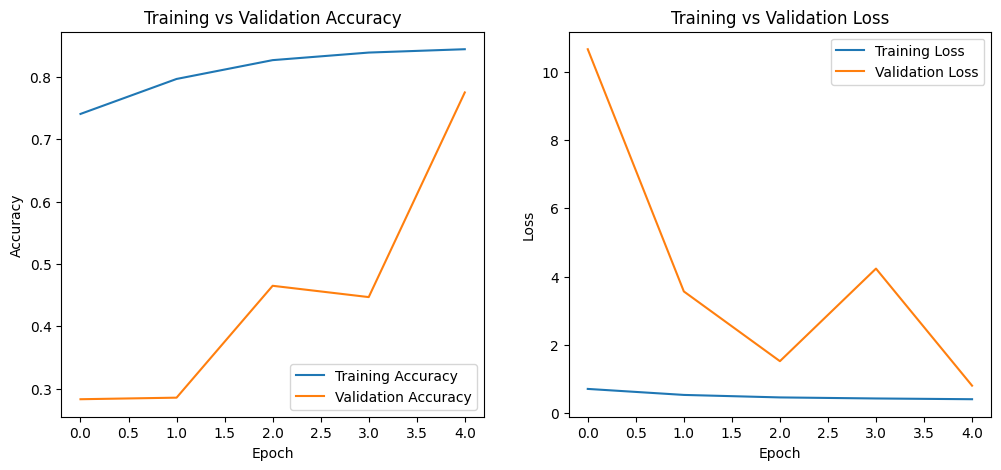

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [15]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.7750 - loss: 0.8095
Test Loss: 0.8094845414161682
Test Accuracy: 0.7749999761581421


50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step
Classification Report:

              precision    recall  f1-score   support

      glioma       0.83      0.70      0.76       400
  meningioma       0.81      0.44      0.57       400
     notumor       0.74      0.98      0.84       400
   pituitary       0.76      0.98      0.85       400

    accuracy                           0.78      1600
   macro avg       0.79      0.78      0.76      1600
weighted avg       0.79      0.78      0.76      1600



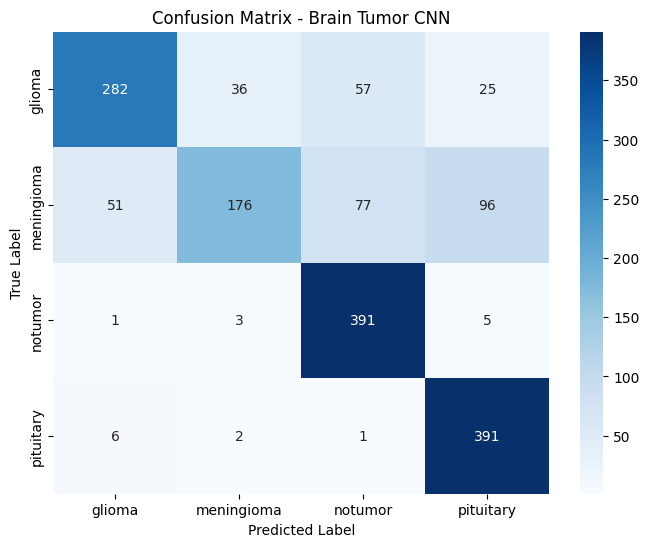

In [16]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Reset test generator
test_generator.reset()

# True labels
y_true = test_generator.classes

# Predictions
y_prob = model.predict(test_generator)
y_pred = np.argmax(y_prob, axis=1)

# Class names
class_names = list(test_generator.class_indices.keys())

# Classification Report
print("Classification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Brain Tumor CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [17]:
from tensorflow.keras.applications import VGG16
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("VGG16 loaded successfully!")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
VGG16 loaded successfully!


In [18]:
for layer in base_model.layers:
    layer.trainable = False

print("VGG16 layers frozen successfully!")

VGG16 layers frozen successfully!


In [19]:
model_vgg = tf.keras.Sequential([
    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(4, activation="softmax")
])

model_vgg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,068 (56.64 MB)

 Trainable params: 132,868 (519.02 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [20]:
model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("VGG16 model compiled successfully!")

VGG16 model compiled successfully!


In [21]:
early_stopping_vgg = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_vgg = model_vgg.fit(
    train_generator,
    validation_data=test_generator,
    epochs=5,
    callbacks=[early_stopping_vgg]
)

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 110s 541ms/step - accuracy: 0.6352 - loss: 0.9226 - val_accuracy: 0.7225 - val_loss: 1.0576
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 124s 519ms/step - accuracy: 0.7695 - loss: 0.6181 - val_accuracy: 0.7781 - val_loss: 0.7401
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 142s 519ms/step - accuracy: 0.7968 - loss: 0.5493 - val_accuracy: 0.7756 - val_loss: 0.6811
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 90s 515ms/step - accuracy: 0.8145 - loss: 0.5102 - val_accuracy: 0.7969 - val_loss: 0.6484
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 90s 515ms/step - accuracy: 0.8316 - loss: 0.4670 - val_accuracy: 0.7931 - val_loss: 0.6707


In [22]:
test_loss_vgg, test_accuracy_vgg = model_vgg.evaluate(test_generator)

print("VGG16 Test Loss:", test_loss_vgg)
print("VGG16 Test Accuracy:", test_accuracy_vgg)

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 189ms/step - accuracy: 0.7969 - loss: 0.6484
VGG16 Test Loss: 0.6484327912330627
VGG16 Test Accuracy: 0.796875


# VGG16 Confusion Matrix + Classification Report

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 185ms/step
VGG16 Classification Report:

              precision    recall  f1-score   support

      glioma       0.79      0.69      0.74       400
  meningioma       0.79      0.53      0.63       400
     notumor       0.81      0.99      0.89       400
   pituitary       0.79      0.98      0.87       400

    accuracy                           0.80      1600
   macro avg       0.80      0.80      0.78      1600
weighted avg       0.80      0.80      0.78      1600



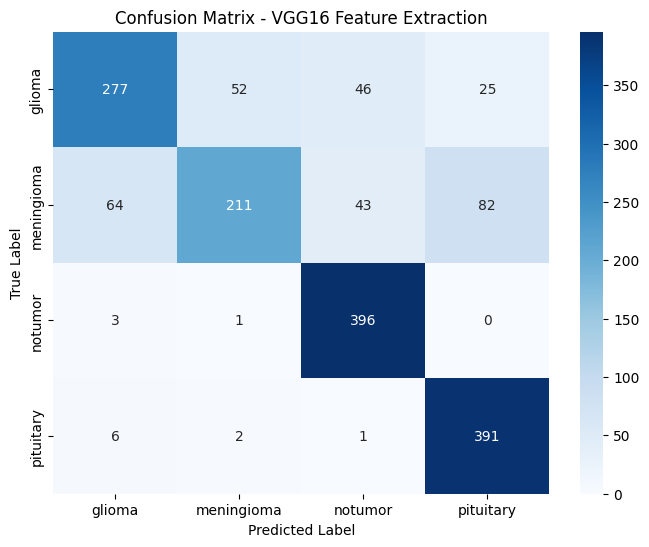

In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Test generator reset
test_generator.reset()

# True labels
y_true_vgg = test_generator.classes

# Predictions
y_prob_vgg = model_vgg.predict(test_generator)

# Convert probabilities to class labels
y_pred_vgg = np.argmax(y_prob_vgg, axis=1)

# Class names
class_names = list(test_generator.class_indices.keys())

# Classification Report
print("VGG16 Classification Report:\n")
print(classification_report(
    y_true_vgg,
    y_pred_vgg,
    target_names=class_names
))

# Confusion Matrix
cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_vgg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - VGG16 Feature Extraction")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# fine tuning

In [24]:
# Freeze all VGG16 layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze only the last convolutional block
for layer in base_model.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True

print("Trainable layers:")
for layer in base_model.layers:
    if layer.trainable:
        print(layer.name)

Trainable layers:
block5_conv1
block5_conv2
block5_conv3
block5_pool


In [25]:
model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
history_finetune = model_vgg.fit(
    train_generator,
    validation_data=test_generator,
    epochs=5,
    callbacks=[early_stopping_vgg]
)

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 101s 537ms/step - accuracy: 0.8512 - loss: 0.4154 - val_accuracy: 0.8413 - val_loss: 0.5249
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 93s 527ms/step - accuracy: 0.8868 - loss: 0.3162 - val_accuracy: 0.8344 - val_loss: 0.5816
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 99s 566ms/step - accuracy: 0.9079 - loss: 0.2624 - val_accuracy: 0.8388 - val_loss: 0.5836
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 93s 532ms/step - accuracy: 0.9204 - loss: 0.2236 - val_accuracy: 0.8769 - val_loss: 0.4848
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 92s 528ms/step - accuracy: 0.9304 - loss: 0.2000 - val_accuracy: 0.8806 - val_loss: 0.4713


In [73]:
test_generator.reset()

test_loss_finetune, test_accuracy_finetune = model_vgg.evaluate(
    test_generator, verbose=1
)

print("Fine-Tuned VGG16 Test Loss:", test_loss_finetune)
print("Fine-Tuned VGG16 Test Accuracy:", test_accuracy_finetune)

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 188ms/step - accuracy: 0.8806 - loss: 0.4713
Fine-Tuned VGG16 Test Loss: 0.4713311791419983
Fine-Tuned VGG16 Test Accuracy: 0.8806250095367432


# Confusion Matrix + Classification Report

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 198ms/step
Final VGG16 Classification Report:

              precision    recall  f1-score   support

      glioma       0.99      0.63      0.77       400
  meningioma       0.77      0.90      0.83       400
     notumor       0.90      1.00      0.95       400
   pituitary       0.92      0.99      0.96       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600



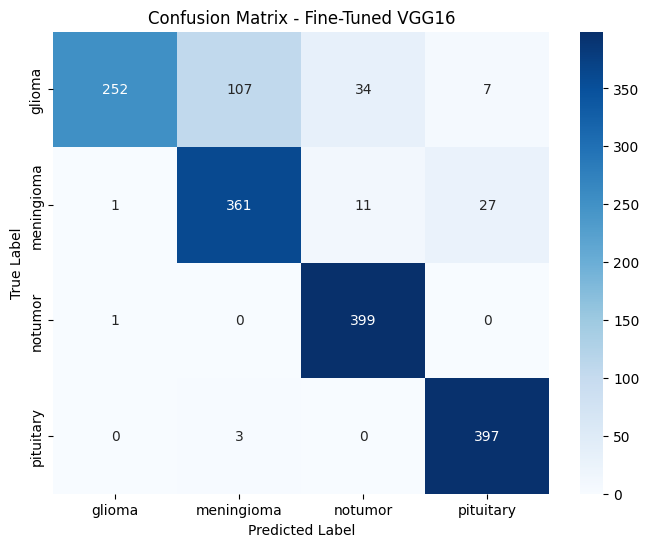

In [74]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

test_generator.reset()

y_true = test_generator.classes
y_prob = model_vgg.predict(test_generator)
y_pred = np.argmax(y_prob, axis=1)

class_names = list(test_generator.class_indices.keys())

print("Final VGG16 Classification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Fine-Tuned VGG16")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [75]:
for layer in base_model.layers:
    print(layer.name)

input_layer_1
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_pool
block4_conv1
block4_conv2
block4_conv3
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_pool


In [76]:
dummy_input = tf.zeros((1, 224, 224, 3))

_ = model_vgg(dummy_input)

print("Model input initialized successfully!")

Model input initialized successfully!


# Grad-CAM Model Create

In [66]:
def make_gradcam_heatmap(img_array, model_vgg, pred_index=None):

    vgg_base = model_vgg.get_layer("vgg16")
    last_conv_layer = vgg_base.get_layer("block5_conv3")

    with tf.GradientTape() as tape:

        conv_outputs = vgg_base(img_array, training=False)
        tape.watch(conv_outputs)

        x = conv_outputs

        for layer in model_vgg.layers[1:]:
            x = layer(x, training=False)

        predictions = x

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if max_value != 0:
        heatmap /= max_value

    return heatmap.numpy()

In [67]:
def detect_and_display(image_path, model_vgg):

    import numpy as np
    import matplotlib.pyplot as plt
    import cv2
    from tensorflow.keras.preprocessing import image

    class_names = [
        'glioma',
        'meningioma',
        'notumor',
        'pituitary'
    ]

    # Load image
    img = image.load_img(
        image_path,
        target_size=(224, 224)
    )

    img_array = image.img_to_array(img) / 255.0
    img_input = np.expand_dims(img_array, axis=0)

    # Prediction
    predictions = model_vgg.predict(
        img_input,
        verbose=0
    )[0]

    predicted_index = np.argmax(predictions)

    predicted_class = class_names[predicted_index]

    confidence = predictions[predicted_index]

    # Grad-CAM
    heatmap = make_gradcam_heatmap(
        img_input,
        model_vgg,
        pred_index=predicted_index
    )

    # Original image
    original_img = cv2.imread(image_path)

    original_img = cv2.cvtColor(
        original_img,
        cv2.COLOR_BGR2RGB
    )

    # Resize heatmap
    heatmap = cv2.resize(
        heatmap,
        (original_img.shape[1], original_img.shape[0])
    )

    heatmap_uint8 = np.uint8(
        255 * heatmap
    )

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    # Combine
    gradcam = cv2.addWeighted(
        original_img,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    # Display
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)

    plt.imshow(original_img)

    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )

    plt.axis("off")

    plt.subplot(1, 2, 2)

    plt.imshow(gradcam)

    plt.title("Grad-CAM")

    plt.axis("off")

    plt.tight_layout()

    plt.show()

    # Print result
    print("Predicted Class:", predicted_class)
    print(
        "Confidence:",
        f"{confidence * 100:.2f}%"
    )

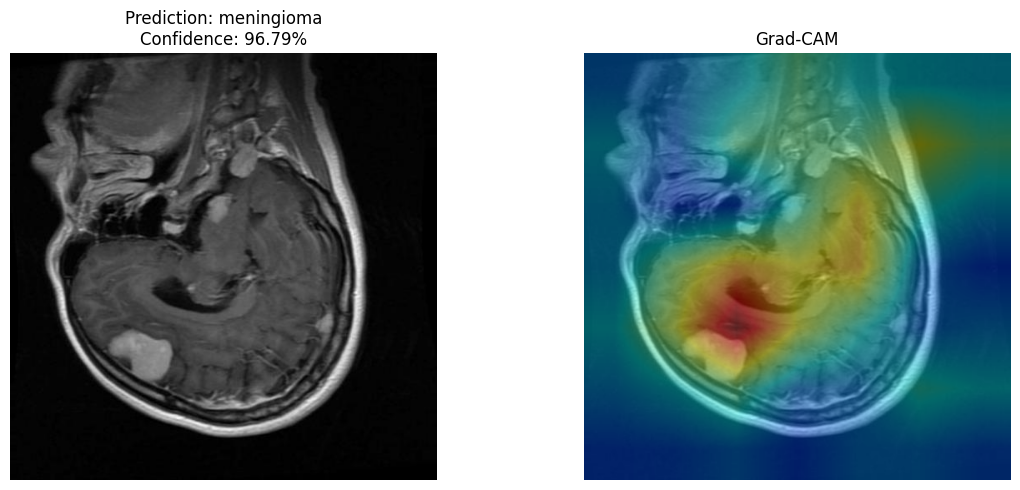

Predicted Class: meningioma
Confidence: 96.79%


In [71]:
image_path = '/content/Tr-aug-me_16.jpg'

detect_and_display(image_path, model_vgg)

In [77]:
model_vgg.save("/content/brain_tumor_vgg16_final.keras")

In [78]:
import os

print(os.path.exists("/content/brain_tumor_vgg16_final.keras"))

True


In [79]:
from google.colab import files

files.download("/content/brain_tumor_vgg16_final.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>